In [1]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\Sachin Kuhikar\Documents\SmartVendor-AI\.venv\Scripts\python.exe
3.13.14 (tags/v3.13.14:fd17997, Jun 10 2026, 13:03:48) [MSC v.1944 64 bit (AMD64)]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
file_path = "../data/raw/Indian FMCG Retail Sales  Customer  Inventory (2024).csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (100000, 21)


In [6]:
df.columns.tolist()

['Invoice_ID',
 'Invoice_Date',
 'City',
 'Store_Format',
 'Category',
 'Brand',
 'Channel',
 'Payment_Mode',
 'Units',
 'Cost_Price',
 'Selling_Price',
 'Revenue',
 'Cost',
 'Margin',
 'Margin_%',
 'Stock_On_Hand',
 'Reorder_Level',
 'Lead_Time_Days',
 'Customer_Age',
 'Customer_Gender',
 'Loyalty_Flag']

In [7]:
df.head()

,Invoice_ID,Invoice_Date,City,Store_Format,Category,Brand,Channel,Payment_Mode,Units,Cost_Price,...,Revenue,Cost,Margin,Margin_%,Stock_On_Hand,Reorder_Level,Lead_Time_Days,Customer_Age,Customer_Gender,Loyalty_Flag
0,58018430,2024-02-02 13:50:00,Kolkata,Super,Grocery,Nestle,Online,Wallet,2,148.999035,...,350.114418,297.998070,52.116348,0.148855,154,31,11,20.0,M,1
1,48157952,2024-10-09 11:52:00,Hyderabad,Hyper,Home Care,PepsiCo,Offline,Wallet,1,80.626759,...,106.034197,80.626759,25.407438,0.239616,130,24,5,26.0,F,1
2,23283831,2024-08-26 22:03:00,Chennai,Hyper,Snacks,PepsiCo,Online,Card,5,181.233170,...,1044.900114,906.165848,138.734266,0.132773,270,44,8,27.0,F,0
3,53537460,2024-06-09 04:34:00,Bengaluru,Hyper,Beverages,Nestle,Omnichannel,Card,2,195.811402,...,521.759920,391.622805,130.137115,0.249420,403,63,8,NaN,F,0
4,55348596,2024-06-07 01:13:00,Delhi,Super,Snacks,ITC,Offline,Card,3,23.571888,...,91.873416,70.715665,21.157751,0.230292,366,40,9,60.0,F,1


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Invoice_ID       100000 non-null  int64  
 1   Invoice_Date     100000 non-null  str    
 2   City             100000 non-null  str    
 3   Store_Format     100000 non-null  str    
 4   Category         100000 non-null  str    
 5   Brand            100000 non-null  str    
 6   Channel          100000 non-null  str    
 7   Payment_Mode     100000 non-null  str    
 8   Units            100000 non-null  int64  
 9   Cost_Price       100000 non-null  float64
 10  Selling_Price    100000 non-null  float64
 11  Revenue          100000 non-null  float64
 12  Cost             100000 non-null  float64
 13  Margin           100000 non-null  float64
 14  Margin_%         100000 non-null  float64
 15  Stock_On_Hand    100000 non-null  int64  
 16  Reorder_Level    100000 non-null  int64  
 17  Lea

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": (missing / len(df)) * 100
})

missing_df[missing_df["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Customer_Age,40081,40.081
Customer_Gender,5048,5.048


In [11]:
df["Customer_Age"] = df["Customer_Age"].fillna(
    df["Customer_Age"].median()
)

print("Missing Customer_Age:", df["Customer_Age"].isnull().sum())

Missing Customer_Age: 0


In [12]:
df["Customer_Gender"] = df["Customer_Gender"].fillna(
    df["Customer_Gender"].mode()[0]
)

print("Missing Customer_Gender:", df["Customer_Gender"].isnull().sum())

Missing Customer_Gender: 0


In [14]:
print(df.isnull().sum().sum())

0


In [15]:
df.dtypes

Invoice_ID           int64
Invoice_Date           str
City                   str
Store_Format           str
Category               str
Brand                  str
Channel                str
Payment_Mode           str
Units                int64
Cost_Price         float64
Selling_Price      float64
Revenue            float64
Cost               float64
Margin             float64
Margin_%           float64
Stock_On_Hand        int64
Reorder_Level        int64
Lead_Time_Days       int64
Customer_Age       float64
Customer_Gender        str
Loyalty_Flag         int64
dtype: object

In [16]:
df["Invoice_Date"] = pd.to_datetime(df["Invoice_Date"])

print(df["Invoice_Date"].dtype)

datetime64[us]


In [17]:
df["Month"] = df["Invoice_Date"].dt.month

print(df["Month"].head())

0     2
1    10
2     8
3     6
4     6
Name: Month, dtype: int32


In [18]:
df["Day_of_Week"] = df["Invoice_Date"].dt.dayofweek

print(df["Day_of_Week"].head())

0    4
1    2
2    0
3    6
4    4
Name: Day_of_Week, dtype: int32


In [19]:
df["Year"] = df["Invoice_Date"].dt.year

print(df["Year"].head())

0    2024
1    2024
2    2024
3    2024
4    2024
Name: Year, dtype: int32


In [20]:
df.describe()

,Invoice_ID,Invoice_Date,Units,Cost_Price,Selling_Price,Revenue,Cost,Margin,Margin_%,Stock_On_Hand,Reorder_Level,Lead_Time_Days,Customer_Age,Loyalty_Flag,Month,Day_of_Week,Year
count,1.000000e+05,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0
mean,5.512347e+07,2024-07-01 10:48:28.414800,2.998290,104.859625,131.107353,393.351350,314.614493,78.736857,0.193368,274.156670,49.467710,8.516810,41.045910,0.297200,6.498370,2.983210,2024.0
min,1.000120e+07,2024-01-01 00:00:00,1.000000,10.000526,10.580915,10.653198,10.002024,0.556870,0.047621,50.000000,20.000000,3.000000,18.000000,0.000000,1.000000,0.000000,2024.0
25%,3.271665e+07,2024-04-01 04:27:30,2.000000,57.478508,71.327813,155.415176,125.467072,24.448402,0.131251,161.000000,34.000000,6.000000,37.000000,0.000000,4.000000,1.000000,2024.0
50%,5.518370e+07,2024-07-01 18:21:30,3.000000,104.903700,129.999158,313.349100,252.801900,53.552720,0.200287,274.000000,50.000000,9.000000,41.000000,0.000000,7.000000,3.000000,2024.0
75%,7.751346e+07,2024-09-30 13:00:15,4.000000,152.320122,188.854907,573.063568,462.376451,110.075103,0.259151,387.000000,64.000000,12.000000,45.000000,1.000000,9.000000,5.000000,2024.0
max,9.999632e+07,2024-12-30 23:57:00,5.000000,199.999659,289.699598,1443.134985,999.985219,447.207497,0.310343,499.000000,79.000000,14.000000,64.000000,1.000000,12.000000,6.000000,2024.0
std,2.596457e+07,NaN,1.414619,54.825341,69.862379,297.154653,234.901995,74.236348,0.075143,129.853861,17.305614,3.458274,10.500395,0.457028,3.444932,2.000622,0.0


In [25]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


City:
<ArrowStringArray>
[  'Kolkata', 'Hyderabad',   'Chennai', 'Bengaluru',     'Delhi', 'Ahmedabad',
    'Mumbai',      'Pune']
Length: 8, dtype: str

Store_Format:
<ArrowStringArray>
['Super', 'Hyper', 'Express']
Length: 3, dtype: str

Category:
<ArrowStringArray>
[      'Grocery',     'Home Care',        'Snacks',     'Beverages',
         'Dairy', 'Personal Care',    'Vegetables',        'Fruits']
Length: 8, dtype: str

Brand:
<ArrowStringArray>
['Nestle', 'PepsiCo', 'ITC', 'Tata', 'Britannia', 'Amul', 'Parle', 'HUL']
Length: 8, dtype: str

Channel:
<ArrowStringArray>
['Online', 'Offline', 'Omnichannel']
Length: 3, dtype: str

Payment_Mode:
<ArrowStringArray>
['Wallet', 'Card', 'Cash', 'UPI']
Length: 4, dtype: str

Customer_Gender:
<ArrowStringArray>
['M', 'F', 'O']
Length: 3, dtype: str


C:\Users\Sachin Kuhikar\AppData\Local\Temp\ipykernel_16780\578808310.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [26]:
print(df.describe().T)

                   count                        mean                  min  \
Invoice_ID      100000.0              55123465.48015           10001195.0   
Invoice_Date      100000  2024-07-01 10:48:28.414800  2024-01-01 00:00:00   
Units           100000.0                     2.99829                  1.0   
Cost_Price      100000.0                  104.859625            10.000526   
Selling_Price   100000.0                  131.107353            10.580915   
Revenue         100000.0                   393.35135            10.653198   
Cost            100000.0                  314.614493            10.002024   
Margin          100000.0                   78.736857              0.55687   
Margin_%        100000.0                    0.193368             0.047621   
Stock_On_Hand   100000.0                   274.15667                 50.0   
Reorder_Level   100000.0                    49.46771                 20.0   
Lead_Time_Days  100000.0                     8.51681                  3.0   

In [27]:
print(df[["Units", "Cost_Price", "Selling_Price", "Revenue", "Cost", "Margin", "Stock_On_Hand", "Reorder_Level", "Lead_Time_Days"]].corr())

                   Units  Cost_Price  Selling_Price   Revenue      Cost  \
Units           1.000000    0.002771       0.002565  0.626647  0.634078   
Cost_Price      0.002771    1.000000       0.980739  0.692308  0.700608   
Selling_Price   0.002565    0.980739       1.000000  0.706011  0.687182   
Revenue         0.626647    0.692308       0.706011  1.000000  0.988284   
Cost            0.634078    0.700608       0.687182  0.988284  1.000000   
Margin          0.501979    0.554289       0.651623  0.875647  0.791676   
Stock_On_Hand  -0.000632   -0.003861      -0.003069 -0.002458 -0.002917   
Reorder_Level   0.001444   -0.000134       0.001180  0.001381  0.000422   
Lead_Time_Days -0.001880   -0.002179      -0.001962 -0.003830 -0.003859   

                  Margin  Stock_On_Hand  Reorder_Level  Lead_Time_Days  
Units           0.501979      -0.000632       0.001444       -0.001880  
Cost_Price      0.554289      -0.003861      -0.000134       -0.002179  
Selling_Price   0.651623      

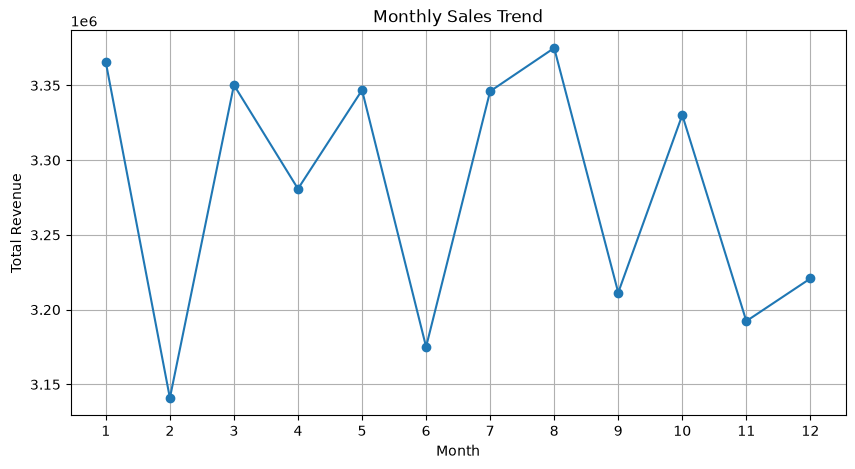

In [28]:
monthly_sales = df.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Monthly Sales Trend")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [29]:
category_sales = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

print(category_sales)

Category
Fruits           4.985418e+06
Grocery          4.947363e+06
Snacks           4.942555e+06
Beverages        4.941030e+06
Home Care        4.931420e+06
Vegetables       4.915302e+06
Personal Care    4.884187e+06
Dairy            4.787859e+06
Name: Revenue, dtype: float64


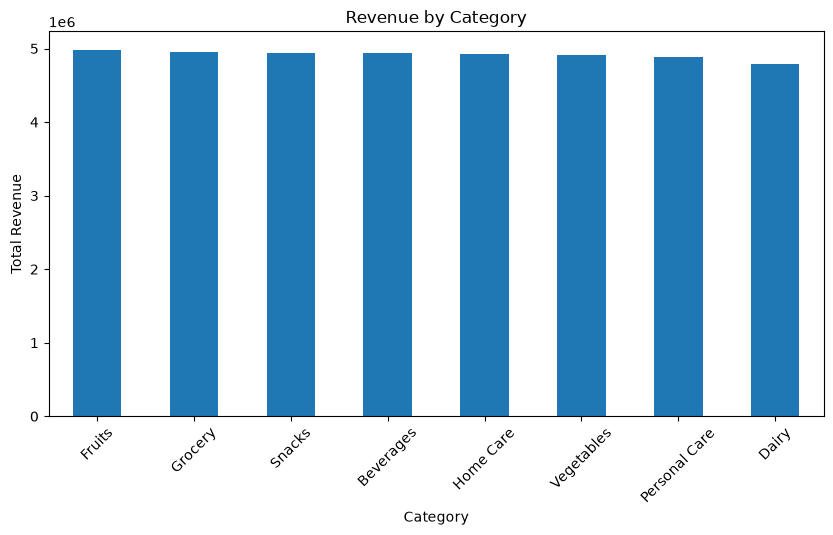

In [30]:
category_sales.plot(kind="bar", figsize=(10, 5))

plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.title("Revenue by Category")
plt.xticks(rotation=45)
plt.show()


In [31]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Infinite values:", np.isinf(df.select_dtypes(include=np.number)).sum().sum())
print("Date null values:", df["Invoice_Date"].isnull().sum())
print("Rows:", len(df))
print("Columns:", len(df.columns))

Missing values: 0
Duplicate rows: 0
Infinite values: 0
Date null values: 0
Rows: 100000
Columns: 24


In [32]:
output_path = "../data/processed/cleaned_data.csv"

df.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
